In [1]:
!mkdir -p ~/.kaggle
!echo "KGAT_563f2f477c2a5f1960a2264a11d335b7" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token


In [2]:
!pip install -q kaggle

!kaggle datasets download -d bmadushanirodrigo/fracture-multi-region-x-ray-data

Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
100% 481M/481M [00:07<00:00, 67.9MB/s]



In [3]:
!unzip fracture-multi-region-x-ray-data.zip

Streaming output truncated to the last 5000 lines.
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2.jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated3 (1).jpg  
  inflating: Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/

In [4]:
import os

print(os.listdir())

['.config', 'fracture-multi-region-x-ray-data.zip', 'README.dataset.txt', 'Bone_Fracture_Binary_Classification', 'sample_data']


In [5]:
dataset_path = "/content/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"
test_dir = dataset_path + "/test"

In [6]:
import os

print(os.listdir(train_dir))

['fractured', 'not fractured']


In [7]:
for category in os.listdir(train_dir):
    path = os.path.join(train_dir, category)
    print(category, len(os.listdir(path)))

fractured 4606
not fractured 4640


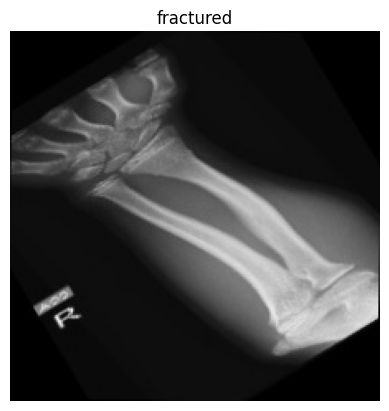

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import random

category = "fractured"

folder = os.path.join(train_dir, category)

img_name = random.choice(os.listdir(folder))

img_path = os.path.join(folder, img_name)

img = Image.open(img_path)

plt.imshow(img, cmap='gray')
plt.title(category)
plt.axis('off')
plt.show()

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True
)

In [12]:
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 9246 images belonging to 2 classes.


In [14]:
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 829 images belonging to 2 classes.


In [15]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 506 images belonging to 2 classes.


In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [17]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
base_model.trainable = False

In [19]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

In [20]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [24]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7499 - loss: 0.4891

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.8147 - loss: 0.4079 - val_accuracy: 0.8504 - val_loss: 0.3528
Epoch 2/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - accuracy: 0.9030 - loss: 0.2690 - val_accuracy: 0.8685 - val_loss: 0.2986
Epoch 3/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - accuracy: 0.9306 - loss: 0.2146 - val_accuracy: 0.8709 - val_loss: 0.2851
Epoch 4/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.9434 - loss: 0.1813 - val_accuracy: 0.8890 - val_loss: 0.2611
Epoch 5/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - accuracy: 0.9547 - loss: 0.1595 - val_accuracy: 0.9083 - val_loss: 0.2441


In [25]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8834 - loss: 0.2656
Test Accuracy: 0.8833991885185242


In [26]:
predictions = model.predict(test_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step


In [27]:
predicted_classes = (predictions > 0.5).astype(int)

In [28]:
true_classes = test_generator.classes

In [29]:
from sklearn.metrics import classification_report

print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       238
           1       0.87      0.92      0.89       268

    accuracy                           0.88       506
   macro avg       0.89      0.88      0.88       506
weighted avg       0.88      0.88      0.88       506



In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [31]:
cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[200  38]
 [ 21 247]]


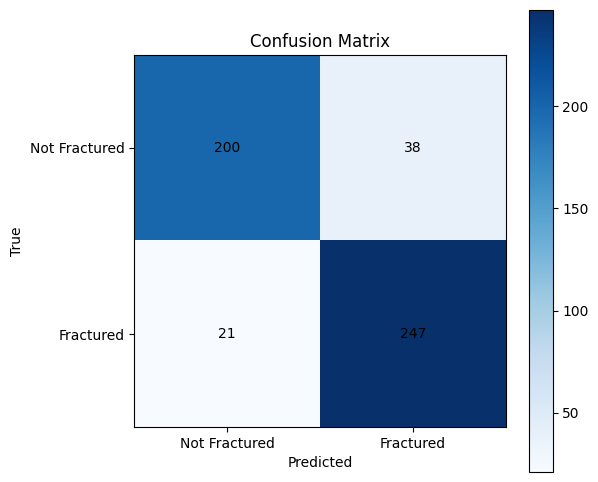

In [32]:
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.colorbar()

classes = ['Not Fractured', 'Fractured']

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 color='black')

plt.show()

In [33]:
model.save("fracture_model.h5")